**420-C74-SF - Techniques d'apprentissage automatique - Automne 2026 - Spécialiste en solutions d'intelligence artificielle**<br/>
© 2026 MKL.AI - Tous droits réservés
<br/>
![Atelier - Régression linéaire simple](static/02-A-banner.png)
<br/>
**Objectif:** cette séance de travaux pratiques propose la résolution **analytique** d'une régression linéaire simple par la **méthode des moindres carrés**. Contrairement à l'algorithme du gradient (chapitre 03), les paramètres du modèle sont ici obtenus par un **calcul direct, sans aucune itération**. Le jeu de données utilisé sera la version simplifiée (une seule variable) du jeu de données *Advertising*

In [39]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

### 0 - Chargement des bibliothèques

In [40]:
# Manipulation de données
import numpy as np
import pandas as pd

# Visualisation de données
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
# Configuration de la visualisation
sns.set_theme(style="darkgrid", rc={'figure.figsize':(11.7,8.27)})

### 1 - Lecture du jeu de données advertising

**Exercice 1-1**: à l'aide de la bibliothèque *pandas*, lire le fichier `advertising-univariate.csv`

In [42]:
# Compléter le code ci-dessous ~ 1 ligne
df = pd.read_csv('/workspaces/420-c74-sf-10017-automne-2026/data/advertising-univariate.csv')

**Exercice 1-2**: à l'aide de la fonction `head()`, visualiser les premières lignes de la trame de données

In [43]:
# Compléter le code ci-dessous ~ 1 ligne
df.head()

,TV,sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


**Exercice 1-3**: combien d'observations le jeu de données contient-il ? Affecter cette valeur à la variable `m`

In [44]:
# Compléter le code ci-dessous ~ 1 ligne
m = len(df)

print(f'Nombre d\'observations: {m}')

Nombre d'observations: 200


<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre réponse. Le `assert` ne doit pas renvoyer d'exception</strong>

In [45]:
assert m == 200

### 2 - Préparation de la structure de données

**Exercice 2**: construire les deux tableaux *numpy* `x` (budget de publicité TV) et `y` (ventes) à partir de la trame de données

Note: contrairement à l'atelier du chapitre 03, aucune mise à l'échelle n'est appliquée ici. Les budgets sont donc exprimés en milliers d'USD.

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
L'attribut <code>.values</code> d'une colonne de trame de données renvoie un tableau <em>numpy</em>.
</p>
</details>

In [46]:
# Compléter le code ci-dessous ~ 2 lignes
x = np.array(df["TV"])
y = np.array(df["sales"])

<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre réponse. Le `assert` ne doit pas renvoyer d'exception</strong>

In [47]:
assert x.shape == (200,)
assert y.shape == (200,)

### 3 - Visualisation des données

La cellule ci-dessous affiche le nuage de points. Chaque point représente un marché: son budget de publicité TV et les ventes observées

Text(0, 0.5, "Ventes (en millier d'unités)")

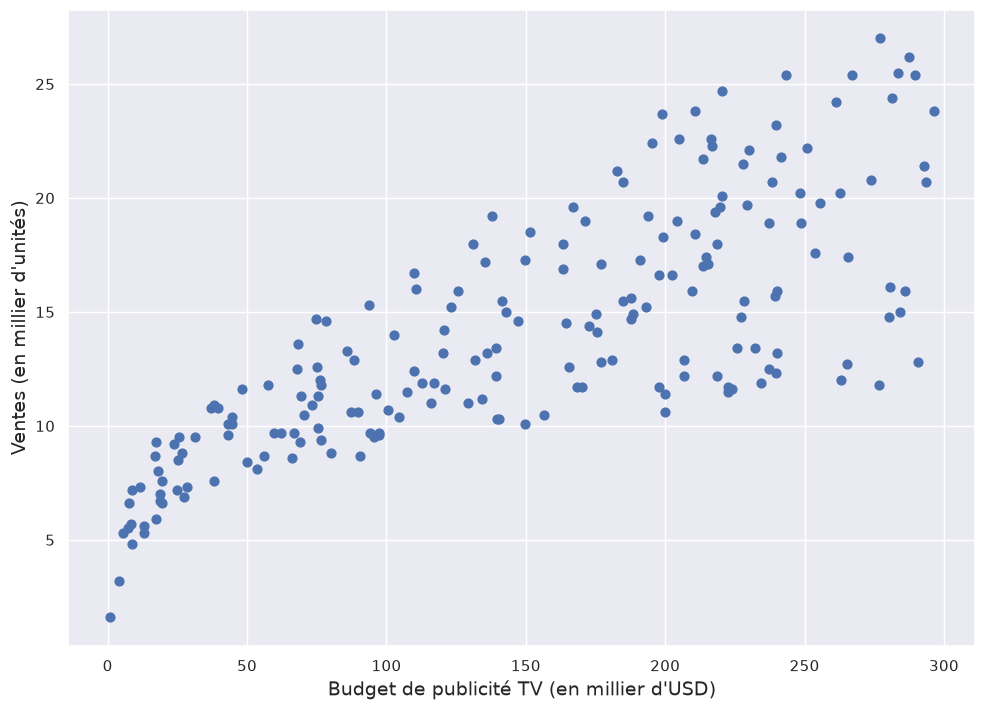

In [48]:
fig, ax = plt.subplots()
ax.scatter(x, y, s=40)
ax.set_xlabel("Budget de publicité TV (en millier d'USD)", fontsize=14)
ax.set_ylabel("Ventes (en millier d'unités)", fontsize=14)

**Question**: la relation entre le budget de publicité TV et les ventes vous semble-t-elle pouvoir être approchée par une droite ? *Oui*

### 4 - Définition du modèle (hypothèse)

**Exercice 3**: compléter la fonction ci-dessous représentant le modèle de régression linéaire simple (hypothèse)

Sachant que l'équation-type d'une régression linéaire simple est:<br>
$h_x = \theta_0 + \theta_1x$

Dans le cadre de la régression linéaire simple, on cherche à trouver une ligne droite qui passe le plus proche possible de tous les points de données (ou "points" ou "observations") dans un ensemble de données. Cette ligne est souvent appelée "la droite de tendance" ou "la droite de régression".

La pente de cette ligne représente la relation linéaire entre la variable explicative X (variable indépendante) et la variable dépendante Y : elle indique combien la valeur de la variable dépendante change en fonction d'un changement unitaire de la variable explicative. Si la pente est positive, cela signifie qu'il y a une relation positive entre les deux variables. C'est-à-dire que lorsque l'une augmente, l'autre tend à augmenter aussi. Si la pente est négative, cela signifie qu'il y a une relation négative, où une augmentation de la première variable entraîne une diminution de la deuxième.

Cependant, il est important de noter que cette ligne ne représente pas toujours parfaitement les données et peut être influencée par des valeurs aberrantes. En outre, dans le cadre plus large du machine learning et de l'analyse statistique, on utilise souvent d'autres types de régressions (comme la régression polynômiale, la régression logistique, etc.) pour représenter de relations non linéaires entre les variables.

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
Pour rappel, le modèle de régression linéaire simple est
$h_{\theta}(x)=\theta_{0} + \theta_{1}x$
</p>
</details>

In [49]:
def hypothesis(x, theta_0, theta_1):
    # Compléter le code ci-dessous ~ 1 ligne
    # Hypothèse: méthode des moindres carrès
    h = theta_0 + (theta_1 * x)
    return h

<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre réponse. Le `assert` ne doit pas renvoyer d'exception</strong>

In [50]:
assert np.allclose(hypothesis(np.array([0.0, 1.0, 2.0]), 1.0, 2.0), np.array([1.0, 3.0, 5.0]))

### 5 - Résidus et somme des carrés des résidus

Le **résidu** est l'écart vertical entre une observation et la droite (l'hypothèse):

$e^{(i)} = y^{(i)} - h_{\theta}(x^{(i)})$

$e^{(i)}$ : C'est le résidu ou l'erreur pour le i-ème échantillon. C'est la différence entre la valeur réelle $y^{(i)}$ et la prédiction $h_\theta(x^{(i)})$ fait par notre modèle.

$y^{(i)}$ : C'est la valeur réelle (ou observée) pour le i-ème échantillon. C'est ce que nous essayons de prédire.

$h_\theta(x^{(i)})$ : C'est la prédiction faite par le modèle que nous avons construit. Le symbole "h" est souvent utilisé pour représenter une fonction d'hypothèse, et "theta" est un ensemble de paramètres ajustés (ou appris) par notre modèle. Ce terme représente donc l'output du modèle lorsque nous lui passons la i-ème entrée $x^{(i)}$.

En résumé, cette équation décrit comment l'erreur est calculée à partir de la prédiction du modèle pour un échantillon spécifique. Si l'erreur est grande (positive ou négative), cela signifie que le modèle a mal prédit la valeur réelle. Si l'erreur est proche de zéro, cela signifie que la prédiction du modèle est précise.

En statistique et en apprentissage automatique, le "résidu" est une mesure du décalage entre les valeurs prévues (par un modèle, y' ) et les observations (y). En d'autres termes, il mesure l'erreur de prédiction commise par le modèle pour chaque observation.

La formule pour le résidu est :
Residual = y - ŷ

où :<br>
- y est la valeur observée<br>
- ŷ est la valeur prédite par le modèle (qui est généralement la valeur prédite par une régression linéaire ou un autre modèle de prévision)<br>

Dans le cas d'une régression linéaire simple, ŷ serait calculé à partir des coefficients de régression (theta_0 et theta_1) :
ŷ = θ₀ + θ₁ * x

Ainsi, le résidu est simplement la différence entre la valeur observée y et la valeur prédite ŷ. Il ne repose pas sur une régression linéaire complète, mais plutôt sur l'écart entre la valeur observée et sa prédiction.

Il est important de noter que les résidus sont utilisés pour diagnostiquer le modèle : par exemple, ils peuvent nous aider à voir s'il y a des tendances non captées par le modèle, ou s'il y a une dispersion non uniforme.

**Exercice 4**: compléter la fonction ci-dessous permettant le calcul des résidus

In [51]:
def residuals(x, y, theta_0, theta_1):
    assert len(x) == len(y)
    # Compléter le code ci-dessous ~ 1 ligne
    # e = y - (theta_0 + (theta_1 * x))
    e = y - hypothesis(x, theta_0, theta_1)
    return e

<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre réponse. Le `assert` ne doit pas renvoyer d'exception</strong>

In [52]:
assert np.allclose(
    residuals(np.array([0.0, 1.0, 2.0]), np.array([1.0, 2.0, 7.0]), 1.0, 2.0),
    np.array([0.0, -1.0, 2.0])
)

**Exercice 5**: compléter la fonction ci-dessous permettant le calcul de la somme des carrés des résidus

On élève au carré chaque résidu, puis on les additionne. Le carré évite l'annulation des signes et pénalise les grands écarts. La quantité à minimiser est la **somme des carrés des résidus** (*residual sum of squares*):

$\text{RSS}(\theta_{0},\theta_{1}) = \sum\limits_{i=1}^{m}\left(y^{(i)} - h_{\theta}(x^{(i)})\right)^{2}$

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
Les fonctions <code>np.sum</code> et l'opérateur <code>**</code> suffisent.
</p>
</details>

In [53]:
def rss(x, y, theta_0, theta_1):
    # Compléter le code ci-dessous ~ 1 ligne
    # s = np.sum((y - (theta_0 + (theta_1 * x)))**2)
    s = np.sum((y - (hypothesis(x, theta_0, theta_1)))**2)
    return s

<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre réponse. Le `assert` ne doit pas renvoyer d'exception</strong>

In [54]:
assert np.isclose(rss(np.array([0.0, 1.0, 2.0]), np.array([1.0, 2.0, 7.0]), 1.0, 2.0), 5.0)

### 6 - Ajustement manuel des paramètres

**Exercice 6**: avant de passer au calcul direct, faites varier à la main $\theta_{0}$ et $\theta_{1}$ de manière à obtenir le meilleur ajustement possible. Le titre du graphique affiche le RSS correspondant: cherchez à le rendre le plus petit possible

Notez la valeur du plus petit RSS que vous parvenez à obtenir, elle servira de point de comparaison à la section 7

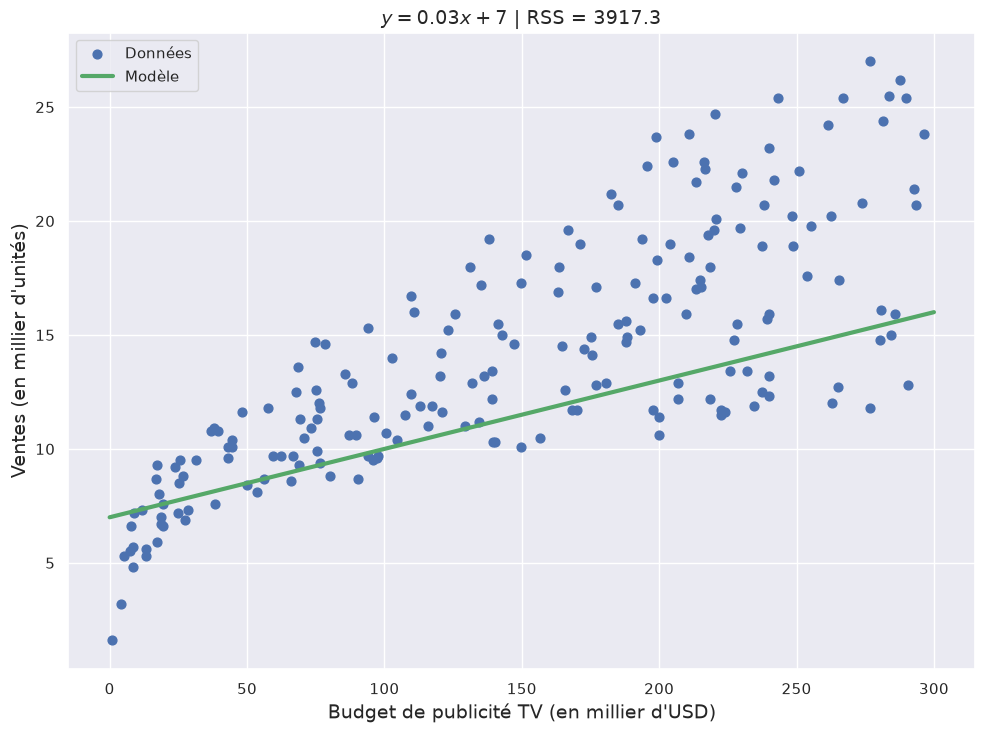

In [58]:
import sympy as sp

# 1. On définit la variable symbolique x
x_sym = sp.Symbol('x')

# Faire varier les deux valeurs ci-dessous ~ 2 lignes
theta_0 = 7
theta_1 = 0.03

# 2. On crée l'équation symbolique avec vos vraies valeurs
# SymPy va combiner 7 + 0.03 * x_sym en une expression mathématique
equation_sym = theta_0 + theta_1 * x_sym

# 3. On génère le code LaTeX propre (ex: "0.03 x + 7")
latex_formula = sp.latex(equation_sym)

reg_x = np.linspace(0, 300, 10)
reg_y = hypothesis(reg_x, theta_0, theta_1)

fig, ax = plt.subplots()
ax.scatter(x, y, s=40, label="Données")
ax.plot(reg_x, reg_y, color="g", lw=3, label="Modèle")
ax.set_xlabel("Budget de publicité TV (en millier d'USD)", fontsize=14)
ax.set_ylabel("Ventes (en millier d'unités)", fontsize=14)

# 4. On affiche la formule LaTeX ET le RSS dans le titre
# Le "r" devant les guillemets est crucial pour que Matplotlib lise le LaTeX correctement
ax.set_title(r"$y = " + latex_formula + f"$ | RSS = {rss(x, y, theta_0, theta_1):.1f}", fontsize=14)

ax.legend(loc='upper left')
plt.show()

### 7 - La méthode des moindres carrés

Plutôt que de tâtonner, les paramètres qui minimisent le RSS s'obtiennent par un **calcul direct**. En annulant les dérivées partielles du RSS par rapport à $\theta_{0}$ et $\theta_{1}$, on obtient les deux formules des moindres carrés:

$\theta_{1} = \dfrac{\sum\limits_{i=1}^{m}\left(x^{(i)}-\bar{x}\right)\left(y^{(i)}-\bar{y}\right)}{\sum\limits_{i=1}^{m}\left(x^{(i)}-\bar{x}\right)^{2}}
\qquad
\theta_{0} = \bar{y} - \theta_{1}\bar{x}$

où $\bar{x}$ et $\bar{y}$ désignent les moyennes de $x$ et de $y$.

**Aucune itération, aucun pas d'apprentissage: un seul calcul.**

**Exercice 7**: compléter la fonction ci-dessous. Seules les fonctions `np.mean` et `np.sum` sont nécessaires

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
<code>x - x_bar</code> soustrait la moyenne à chaque élément du tableau (diffusion). Le produit <code>*</code> entre deux tableaux <em>numpy</em> est un produit terme à terme, il ne reste plus qu'à en faire la somme.
</p>
</details>

In [ ]:
def least_squares(x, y):
    assert len(x) == len(y)
    # Compléter le code ci-dessous ~ 4 lignes
    x_bar = np.mean(x)
    y_bar = np.mean(y)
    theta_1 = np.sum((x - x_bar) * (y - y_bar))/np.sum((x - x_bar) ** 2)
    theta_0 = y_bar - (theta_1 * x_bar)
    return theta_0, theta_1

En résumé, theta_0 et theta_1 sont des coefficients qui définissent la droite de régression linéaire. La droite de régression est une ligne qui correspond le mieux à nos données (elle minimise les erreurs quadratiques résiduelles).

Theta_0 est l'ordonnée à l'origine, c'est-à-dire où la droite coupe l'axe y. Il représente la valeur de y lorsque x vaut 0.

Theta_1 est le coefficient directeur ou pente de la ligne. Il indique combien y augmente (ou diminue) avec un changement d'une unité dans x. Si theta_1 est positif, cela signifie que y et x ont une relation positive : quand y augmente, x augmente aussi (et vice versa). Si theta_1 est négatif, cela indique une relation négative : quand y augmente, x diminue.

Dans ce cas précis, theta_0 et theta_1 sont calculés directement en utilisant le RSS (residual sum of squares), c'est-à-dire la somme des carrés des écarts entre les valeurs prédites et les observations. On obtient une valeur optimale pour ces coefficients qui minimise le RSS, ce qui signifie que notre droite de régression est la meilleure approximation possible de nos données.

La formule donnée permet de calculer theta_1 comme étant la somme des produits des écarts individuels entre les valeurs y et x par rapport à leur moyenne, divisée par la somme des carrés des écarts individuels de x par rapport à sa moyenne. Theta_0 est ensuite dérivé en utilisant le coefficient directeur theta_1 et la moyenne de x et y.

En résumé : theta_0 et theta_1 sont les paramètres qui définissent la droite de régression, et ils sont calculés en minimisant les erreurs quadratiques entre nos observations et notre modèle.

In [ ]:
theta_0, theta_1 = least_squares(x, y)

print(f'theta_0 = {theta_0}')
print(f'theta_1 = {theta_1}')

theta_0 = 7.0325935491276965
theta_1 = 0.047536640433019736


Les valeurs obtenues devraient être

```
theta_0 = 7.0325935491...
theta_1 = 0.0475366404...
```

<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre réponse. Le `assert` ne doit pas renvoyer d'exception</strong>

In [ ]:
assert np.isclose(theta_0, 7.032594)
assert np.isclose(theta_1, 0.047537)

**Exercice 8**: calculer le RSS obtenu avec ces paramètres, et le comparer à celui de votre ajustement manuel (exercice 6)

In [ ]:
# Compléter le code ci-dessous ~ 1 ligne
rss_optimal = rss(x, y, theta_0, theta_1)

print(f'RSS (moindres carrés) = {rss_optimal:.2f}')

RSS (moindres carrés) = 2102.53


<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre réponse. Le `assert` ne doit pas renvoyer d'exception</strong>

In [ ]:
assert np.isclose(rss_optimal, 2102.5306, atol=1e-3)

**Question**: pouvez-vous trouver, en tâtonnant, un couple $(\theta_{0}, \theta_{1})$ donnant un RSS plus faible ?

*(votre réponse ici)*

### 8 - Affichage de la droite ajustée

La cellule ci-dessous affiche la droite des moindres carrés ainsi que les résidus (segments verticaux rouges)

Ce code Python utilise la bibliothèque NumPy et Matplotlib pour générer une visualisation graphique de
données de publicité TV et des ventes associées. Voici une explication détaillée de chaque ligne :

import numpy as np
Importe la bibliothèque NumPy, qui est utilisée pour le calcul scientifique en Python.

reg_x = np.linspace(0, 300, 10)
Crée un tableau reg_x contenant 10 points équidistants entre 0 et 300. Cela sera utilisé pour générer une ligne de droite des moindres carrés.

reg_y = hypothesis(reg_x, theta_0, theta_1)
Calcule les valeurs prédites reg_y à partir de la fonction hypothétique hypothesis avec les paramètres theta_0 et theta_1. Cette ligne génère une droite des moindres carrés qui représente la meilleure approximation des données.

fig, ax = plt.subplots()
Crée un objet figure (fig) et un axe de dessin (ax) pour afficher l'graphique. plt.subplots() retourne un tuple contenant la figure et les axes.

ax.vlines(x, hypothesis(x, theta_0, theta_1), y, color="r", lw=1, alpha=0.7, label="Résidus")
Trace des lignes verticales (vlines) pour chaque point (x[i], y[i]) avec une ligne rouge (color="r") représentant le résidu entre la valeur réelle y[i] et la prédiction hypothesis(x[i], theta_0, theta_1). Les lignes sont plus fines (lw=1) et semi-transparentes (alpha=0.7). L'étiquette de la ligne est "Résidus".

ax.scatter(x, y, s=40, label="Données")
Affiche les points de données (x[i], y[i]) en tant que marqueurs dispersés avec une taille de marqueur de 40 (s=40). L'étiquette est "Données".

ax.plot(reg_x, reg_y, color="g", lw=3, label="Droite des moindres carrés")
Trace la droite des moindres carrés entre les points reg_x et reg_y avec une couleur verte (color="g") et une épaisseur de ligne de 3 (lw=3). L'étiquette est "Droite des moindres carrés".

ax.set_xlabel("Budget de publicité TV (en millier d'USD)", fontsize=14)
Définit le titre de l'axe des abscisses ("x") en affichant "Budget de publicité TV (en millier d'USD)" avec une taille de police de 14.

ax.set_ylabel("Ventes (en millier d'unités)", fontsize=14)
Définit le titre de l'axe des ordonnées ("y") en affichant "Ventes (en millier d'unités)" avec une taille de police de 14.

ax.set_title(f"RSS = {rss(x, y, theta_0, theta_1):.1f}", fontsize=16)
Définit le titre du graphique en affichant l'erreur quadratique totale (RSS) calculée à partir des données x, y et des paramètres theta_0, theta_1. L'erreur est arrondie au dixième (:.1f) et la taille de police du titre est 16.

ax.legend(loc='upper left')
Ajoute une légende à l'axe des ordonnées, placée en haut à gauche (loc='upper left').

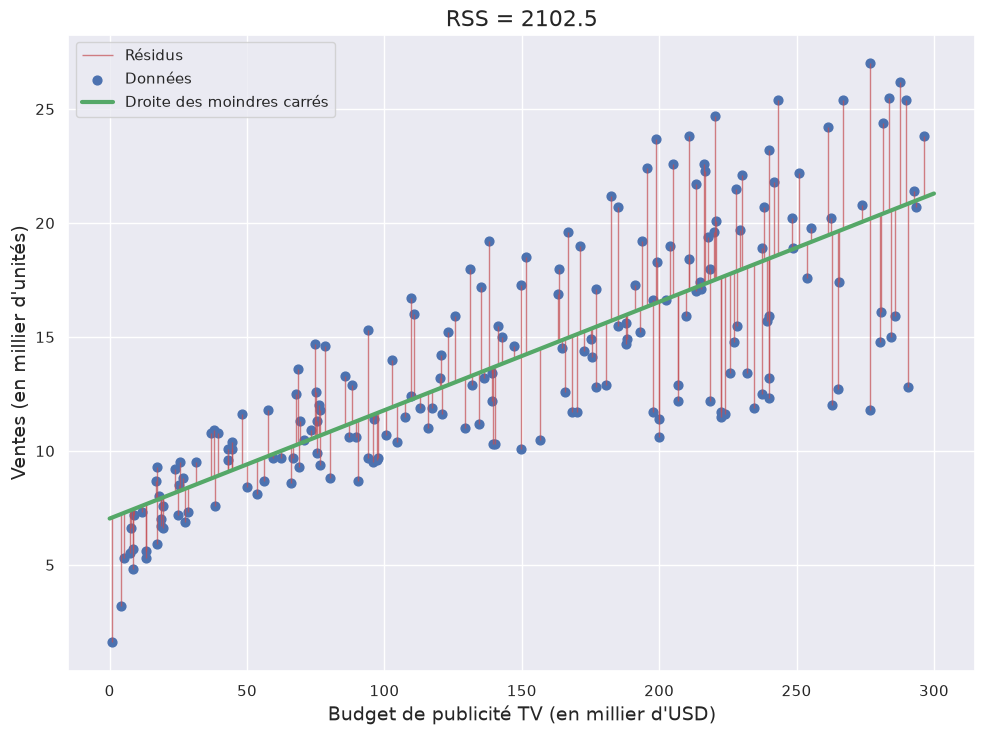

In [ ]:
reg_x = np.linspace(0, 300, 10)
reg_y = hypothesis(reg_x, theta_0, theta_1)

fig, ax = plt.subplots()
ax.vlines(x, hypothesis(x, theta_0, theta_1), y, color="r", lw=1, alpha=0.7, label="Résidus")
ax.scatter(x, y, s=40, label="Données")
ax.plot(reg_x, reg_y, color="g", lw=3, label="Droite des moindres carrés")
ax.set_xlabel("Budget de publicité TV (en millier d'USD)", fontsize=14)
ax.set_ylabel("Ventes (en millier d'unités)", fontsize=14)
ax.set_title(f"RSS = {rss(x, y, theta_0, theta_1):.1f}", fontsize=16)
ax.legend(loc='upper left')

### 9 - Prédiction

**Exercice 9**: quelles ventes le modèle prédit-il sur un nouveau marché où le budget de publicité TV serait de 150 milliers d'USD ?

In [ ]:
budget = 150

# Compléter le code ci-dessous ~ 1 ligne
ventes_predites = 14.163000

print(f'Ventes prédites: {ventes_predites:.2f} milliers d\'unités')

Ventes prédites: 14.16 milliers d'unités


<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre réponse. Le `assert` ne doit pas renvoyer d'exception</strong>

In [ ]:
assert np.isclose(ventes_predites, 14.163090, atol=1e-4)

**Attention**: le modèle n'a été ajusté que sur des budgets compris entre `x.min()` et `x.max()`. Une prédiction pour un budget très éloigné de cet intervalle (une **extrapolation**) n'est pas justifiée par les données.

In [ ]:
print(f'Domaine observé: de {x.min()} à {x.max()} milliers d\'USD')

Domaine observé: de 0.7 à 296.4 milliers d'USD


### 10 - Interprétation des paramètres

**Exercice 10**: dans le contexte du jeu de données *Advertising*, quelle est l'interprétation concrète de $\theta_{0}$ et de $\theta_{1}$ ? Répondre dans la cellule ci-dessous

Ordonnée à l'origine Theta0 = 7.032 signifie que si on n'a rien dépensé en budget de publicité (x = 0), on vend tout de même 7032 unités! Et que pour chaque dollar de budget de publicité investi, on a une augmentation de 0.04754 milliers $us de ventes  --> 47$

Note: l'interprétation de $\theta_{1}$ (et parfois de $\theta_{0}$) est très importante en pratique. Elle dépend des **unités** des variables: si le budget avait été exprimé en centaines de milliers d'USD, comme dans l'atelier du chapitre 03, la valeur de $\theta_{1}$ aurait été multipliée par 100.

### 11 - Vérification

Les formules des moindres carrés peuvent aussi s'écrire à l'aide de la covariance et de la variance:

$\theta_{1} = \dfrac{\text{Cov}(x,y)}{\text{Var}(x)}$

La cellule ci-dessous vérifie que les trois écritures (votre implémentation, la forme covariance/variance et l'ajustement polynomial de degré 1 de *numpy*) donnent bien le même résultat

In [ ]:
# Forme covariance / variance
theta_1_cov = np.cov(x, y, ddof=1)[0, 1] / np.var(x, ddof=1)

# Ajustement polynomial de degré 1 (numpy)
theta_0_np, theta_1_np = np.polynomial.Polynomial.fit(x, y, deg=1).convert().coef

print(f'theta_1 (votre implémentation)     = {theta_1}')
print(f'theta_1 (covariance / variance)    = {theta_1_cov}')
print(f'theta_1 (numpy Polynomial.fit)     = {theta_1_np}')
print()
print(f'theta_0 (votre implémentation)     = {theta_0}')
print(f'theta_0 (numpy Polynomial.fit)     = {theta_0_np}')

assert np.isclose(theta_1, theta_1_cov)
assert np.isclose(theta_1, theta_1_np)
assert np.isclose(theta_0, theta_0_np)

theta_1 (votre implémentation)     = 0.047536640433019736
theta_1 (covariance / variance)    = 0.047536640433019736
theta_1 (numpy Polynomial.fit)     = 0.04753664043301973

theta_0 (votre implémentation)     = 7.0325935491276965
theta_0 (numpy Polynomial.fit)     = 7.032593549127694


### Fin de l'atelier